<a href="https://colab.research.google.com/github/Thomas-Fabbris/MMIP-polimi/blob/main/Assignments/Lez_3_4_DCT_denoising.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook setup

Import the necessary modules, including `google.colab.drive` for accessing the required assets for the notebook (`cameraman.png`) from Google Drive

In [1]:
from skimage.io import imread                # pyright: ignore[reportMissingImports]
from google.colab import drive               # pyright: ignore[reportMissingImports]
import numpy as np
from scipy.fft import dct, idct
from scipy.signal import convolve2d
from scipy.stats import median_abs_deviation  # used for computing MAD
from matplotlib import pyplot as plt
import time

Mount your Google Drive folders, located at `/content/drive`, on the local runtime filesystem and define the root folder for the project

In [2]:
drive.mount('/content/drive', force_remount=True)
ROOT_FOLDER = '/content/drive/MyDrive/MMIP/data'

Mounted at /content/drive


# Denoising

The goal of this section is to implement a simple denoising algorithm based on the 2D DCT. Given a noise-free image $Y$, we observe a noisy version $S$
$$
S = Y + \eta
$$
where $\eta\sim N(0, \sigma^2)$ denotes white Gaussian noise.

Our goal is to compute an estimate $\widehat Y$ of the original image $Y$. To evaluate the performance of the denoising algorithm we use again the PSNR
$$
\text{PSNR} = 10\log_{10}\frac{1}{\text{MSE}(Y, \widehat Y)}
$$

## Synthetically corrupt a noisy image

Load the image and rescale it in $[0,1]$

In [29]:
img = imread(f'{ROOT_FOLDER}/checkerboard.png') / \
    255.0  # /checkerboard.png
imsz = img.shape

Corrupt the image with white gaussian noise

In [30]:
sigma_noise = 20/255
noisy_img = img + np.random.normal(size=imsz) * sigma_noise

Compute the PSNR of the noisy input

In [31]:
psnr_noisy = 10 * np.log10(1/np.square(np.subtract(img, noisy_img)).mean())

Text(0.5, 1.0, 'Noisy image, PSNR = 22.09')

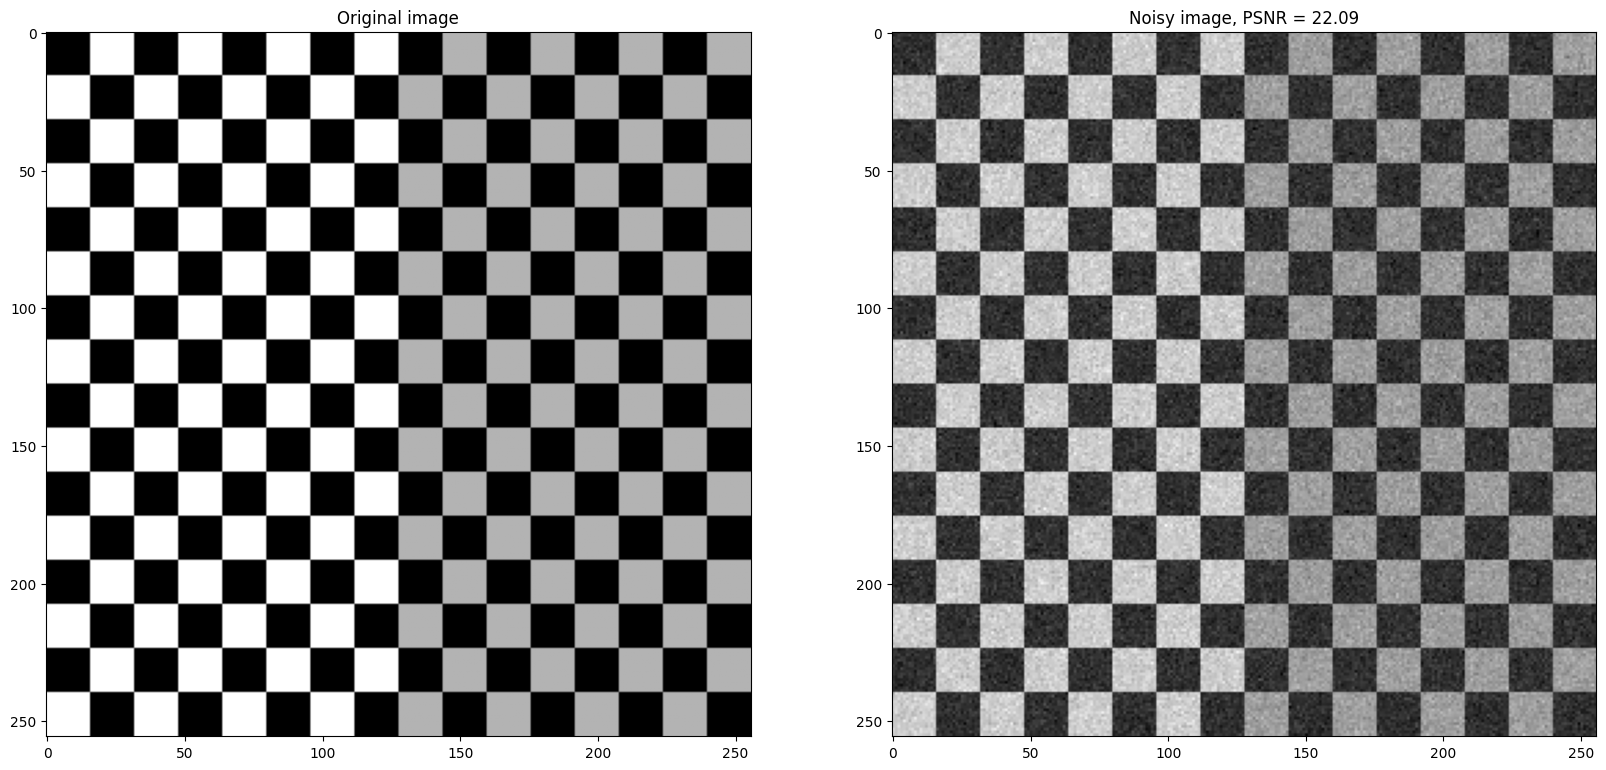

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original image')

ax[1].imshow(noisy_img, cmap='gray')
ax[1].set_title(f'Noisy image, PSNR = {psnr_noisy:.2f}')

Noise estimation
----------------
Compute the horizontal derivative of the image

In [35]:
differences = convolve2d(noisy_img, np.array(
    [[-1, 0, 1]]), mode='same', boundary='symm')

Compute sigma as the empirical std

In [36]:
sigma_hat_emp = np.std(differences) / np.sqrt(2)
sigma_hat_emp

np.float64(0.22355660651790166)

Use MAD to estimate the noise level sigma

In [37]:
# Compute MAD by using scipy.stats.median_abs_deviation
sigma_hat = median_abs_deviation(
    differences, axis=None, scale='normal') / np.sqrt(2)
# Compute MAD "manually"
# sigma_hat = np.median(np.abs(differences - np.median(differences))) / \
#                    (np.sqrt(2) * 0.67449)

In [38]:
print(f'sigma: {sigma_noise:.3f}, sigma_hat (empirical std): {sigma_hat_emp:.3f}, sigma_hat (MAD): {sigma_hat:.3f}')

sigma: 0.078, sigma_hat (empirical std): 0.224, sigma_hat (MAD): 0.091


As expected, both the MAD-based estimate and the empirical estimate of the 
noise standard deviation differ from the true value. However, because MAD is a 
robust estimator for the estimation of the standard deviation provides an 
estimate closer to the effective variability of the noise.

## Denoising by Smoothing
Implement denoising by smoothing using convolution against a uniform filter of different sizes.

In [39]:
filter_size = 11  # @param {type: "slider", min: 3, max: 15, step: 1}
filter = np.full((filter_size, filter_size), 1/(filter_size ** 2))
# Compute the convolution with convolve2d()
img_hat_conv = convolve2d(noisy_img, filter, mode='same', boundary='symm')

In [40]:
psnr_conv = 10 * np.log10(1/np.square(np.subtract(img, img_hat_conv)).mean())

Text(0.5, 1.0, 'Noisy image, PSNR = 22.09')

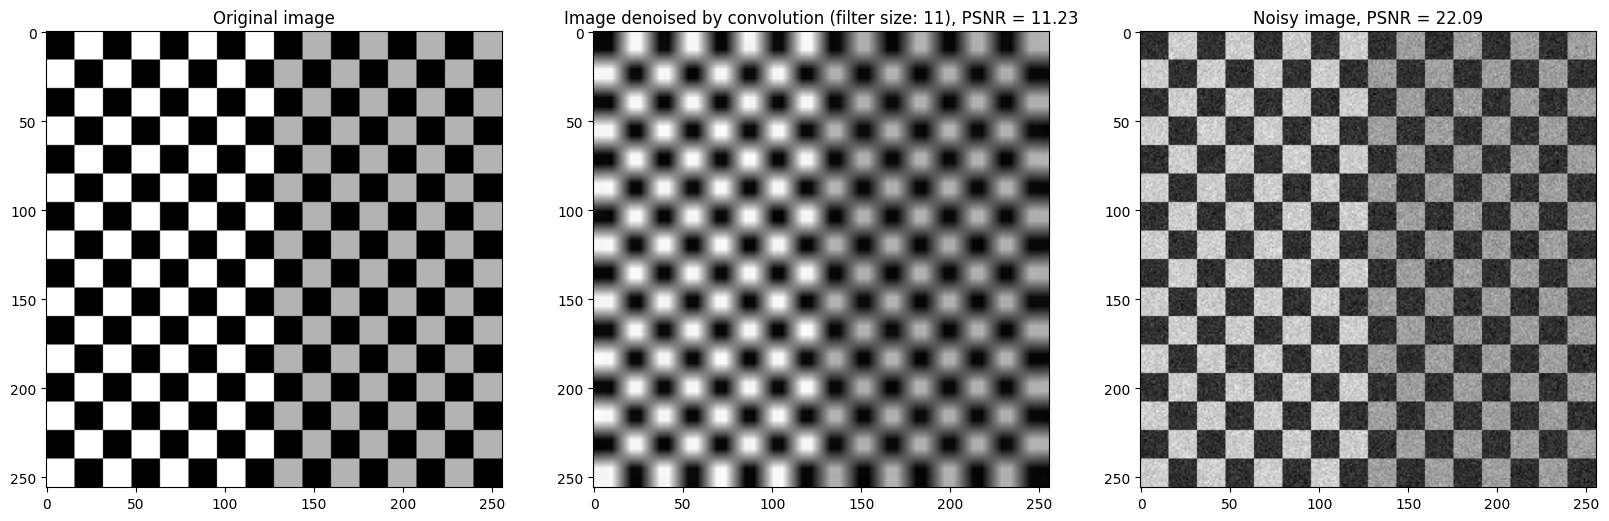

In [41]:
fig, ax = plt.subplots(1, 3, figsize=(20, 10))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original image')

ax[1].imshow(img_hat_conv, cmap='gray')
ax[1].set_title(
    f'Image denoised by convolution (filter size: {filter_size}), PSNR = {psnr_conv:.2f}')

ax[2].imshow(noisy_img, cmap='gray')
ax[2].set_title(f'Noisy image, PSNR = {psnr_noisy:.2f}')

As the kernel size increases, the denoising algorithm causes oversmoothing 
(loss of details and edge sharpness), which degrades reconstruction quality, 
as reflected by lower PSNR.

|Filter size|PSNR (dB)|
|:----:|----:|
|$3 \times 3$|24.96|
|$5 \times 5$|22.86|
|$7 \times 7$|21.65|
|$11 \times 11$|20.26|

## Denoising by Leveraging Sparsity in the DCT Domain

Definition of `dct2()` and `idct2()`

In [42]:
def dct2(s):
    return dct(dct(s.T, norm='ortho').T, norm='ortho')


def idct2(x):
    return idct(idct(x.T, norm='ortho').T, norm='ortho')

In [43]:
p = 8       # Patch size
M = p ** 2  # No. of elements per patch

Useful function for plot the 2D DCT dictionary

In [44]:
def get_dictionary_img(D):
    M = D.shape[0]
    p = int(round(np.sqrt(M)))
    bound = 2
    img = np.ones((p*p+bound*(p-1), p*p+bound*(p-1)))
    for i in range(M):
        m = np.mod(i, p)
        n = int((i-m)/p)
        m = m * p + bound * m
        n = n * p + bound * n
        atom = D[:, i].reshape((p, p))
        if atom.min() < atom.max():
            atom = (atom - atom.min()) / (atom.max() - atom.min())
        img[m: m + p, n: n + p] = atom

    return img

Sliding DCT denoising
-------------
Generate the DCT basis

In [45]:
D = np.zeros((M, M))
cnt = 0
for i in range(p):
    for j in range(p):
        E = np.zeros((p, p))
        E[i, j] = 1.0
        D[:, cnt] = idct2(E).reshape(-1)
        cnt = cnt + 1

(np.float64(-0.5), np.float64(77.5), np.float64(77.5), np.float64(-0.5))

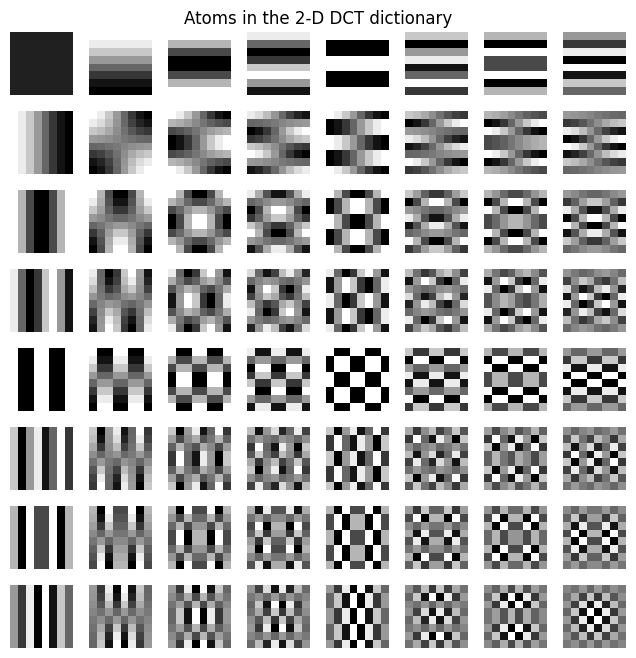

In [46]:
D_img = get_dictionary_img(D)
plt.figure(figsize=(8, 8))
plt.imshow(D_img, cmap='gray')
plt.title('Atoms in the 2-D DCT dictionary')
plt.axis('off')

Denoising: set parameters and initialize the variables

In [47]:
# Initialize the estimated image
img_hat = np.zeros_like(img)

# Initialize the weight matrix
weights = np.zeros_like(img)

# Set the threshold for hard thresholding
tau = 3 * sigma_noise
# tau = 0.02                                    # Case tau << 3 * sigma_noise
# tau = 2.0                                     # Case tau >> 3 * sigma_noise
# tau = sigma_noise * np.sqrt(2 * np.log(M))    # Donoho threshold

# Define the step
# STEP = p                                      # Non-overlapping tiles
STEP = 1                                        # Sliding DCT with homogeneous weights

Perform the sliding-DCT denoising

In [48]:
for i in range(0, imsz[0] - p + 1, STEP):
    for j in range(0, imsz[1] - p + 1, STEP):
        # Extrach the patch
        s = np.reshape(noisy_img[i:i + p, j:j + p], M)

        # Compute the representation w.r.t. the 2D DCT dictionary
        x = D.T @ s

        # Perform the hard thresholding (do not perform HT on the DC!)
        x_HT = x.copy()
        x_HT[1:][np.abs(x_HT[1:]) < tau] = 0.0

        # Perform the reconstruction
        s_hat = D @ x_HT

        # Compute the weights to be used for aggregating the reconstructed patch
        # w = 1                           # Homogeneous weights
        w = 1.0 / np.count_nonzero(x_HT)  # Sparsity-aware weights

        # Accumulate, by summation, the denoised patch into the denoised image
        # using the computed weights
        img_hat[i:i + p, j:j + p] += w * s_hat.reshape(p, p)

        # Accumulate, by summation, the weights of the current patch in the 
        # weight matrix
        weights[i:i + p, j:j + p] += w

Normalize the estimated image with the computed weights, i.e. compute averages

In [49]:
img_hat = np.divide(img_hat, weights, out=np.zeros_like(
    img_hat), where=weights > 0)

The above cell also includes the implementation of DCT denoising in the case 
where non-overlapping tiles are used and no aggregation is performed; 
it is sufficient to initialize `STEP = p` in Cell 36

Compute the PSNR of the estimated image

Text(0.5, 1.0, 'Estimated Image (step: 1), PSNR = 35.65')

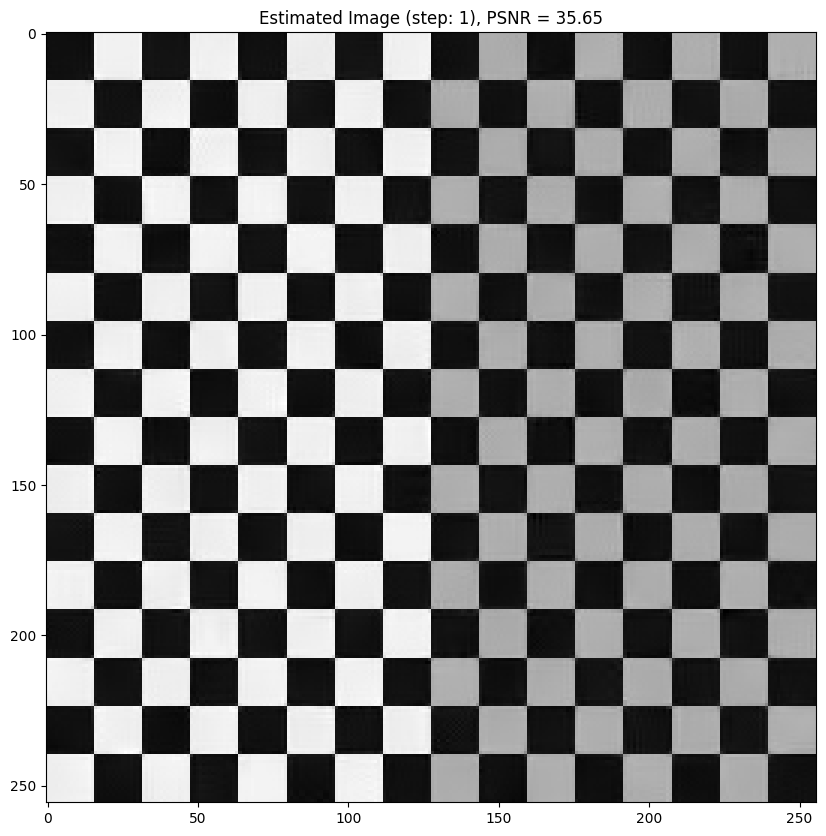

In [50]:
psnr_hat = 10 * np.log10(1.0/np.square(np.subtract(img, img_hat)).mean())
plt.figure(figsize=(10, 10))
plt.imshow(img_hat, cmap='gray')
plt.title(f'Estimated Image (step: {STEP}), PSNR = {psnr_hat:.2f}')

When the threshold $\tau$ is too small ($\tau \ll 3\hat{\sigma}$), very few 
coefficients of `x` are zeroed out during the thresholding phase of the algorithm. 
Consequently, most noise is retained, yielding an 
estimated image that remains visibly noisy. This is reflected in a PSNR value 
comparable to that of the noisy input, indicating poor noise suppression.

Conversely, an excessively large threshold ($\tau \gg 3\hat{\sigma}$) aggressively zeros out the coefficients, destroying fine details and edges. The resulting estimate becomes overly smooth, loosing important image features and yelding a lower PSNR.

The optimal choice is represented by the Donoho universal threshold 
$$\tau = \hat{\sigma}\sqrt{2\log_{10} M}$$
where $\hat{\sigma}$ is the noise 
standard deviation estimated via MAD and $M = p^2$ is the number of 
elements per patch.

Wiener Filtering
----------------
Initialize the estimated image via Wiener Filtering

In [54]:
img_hat_wiener = np.zeros_like(img)
weights = np.zeros_like(img)

Perform the denoising patchwise

In [55]:
for i in range(0, imsz[0] - p + 1, STEP):
    for j in range(0, imsz[1] - p + 1, STEP):
        # Extrach the patch from the noisy image with the top left corner at 
        # pixel (i, j)
        s = np.reshape(noisy_img[i:i + p,j:j + p], M)

        # Compute the representation w.r.t. the 2D DCT dictionary
        x = D.T @ s
        
        # Extrach the patch from the image estimated by HT
        s_hat_HT = np.reshape(img_hat[i:i + p,j:j + p], M)
        
        v_hat_HT = D.T @ s_hat_HT

        # Perform the Wiener filtering (do not filter the DC!)
        x_wie = x.copy()
        x_wie[1:] = (np.square(v_hat_HT[1:]) / (np.square(v_hat_HT[1:]) + sigma_noise ** 2)) * x[1:]

        # Perform the reconstruction
        s_hat_wie = D @ x_wie

        # Use uniform weights to aggregate the multiple estimates
        w = 1

        # Put the denoised patch into the denoised image using the computed weight
        img_hat_wiener[i:i + p, j:j + p] += w * s_hat_wie.reshape(p,p)

        # Store the weight of the current patch in the weight matrix
        weights[i:i + p,j:j + p] += w

# Normalize the estimated image with the computed weights
img_hat_wiener = np.divide(img_hat_wiener, weights, out=np.zeros_like(
    img_hat_wiener), where=weights > 0)

Compute the PSNR of the two estimates

Text(0.5, 1.0, 'Wiener Estimate, PSNR = 32.35')

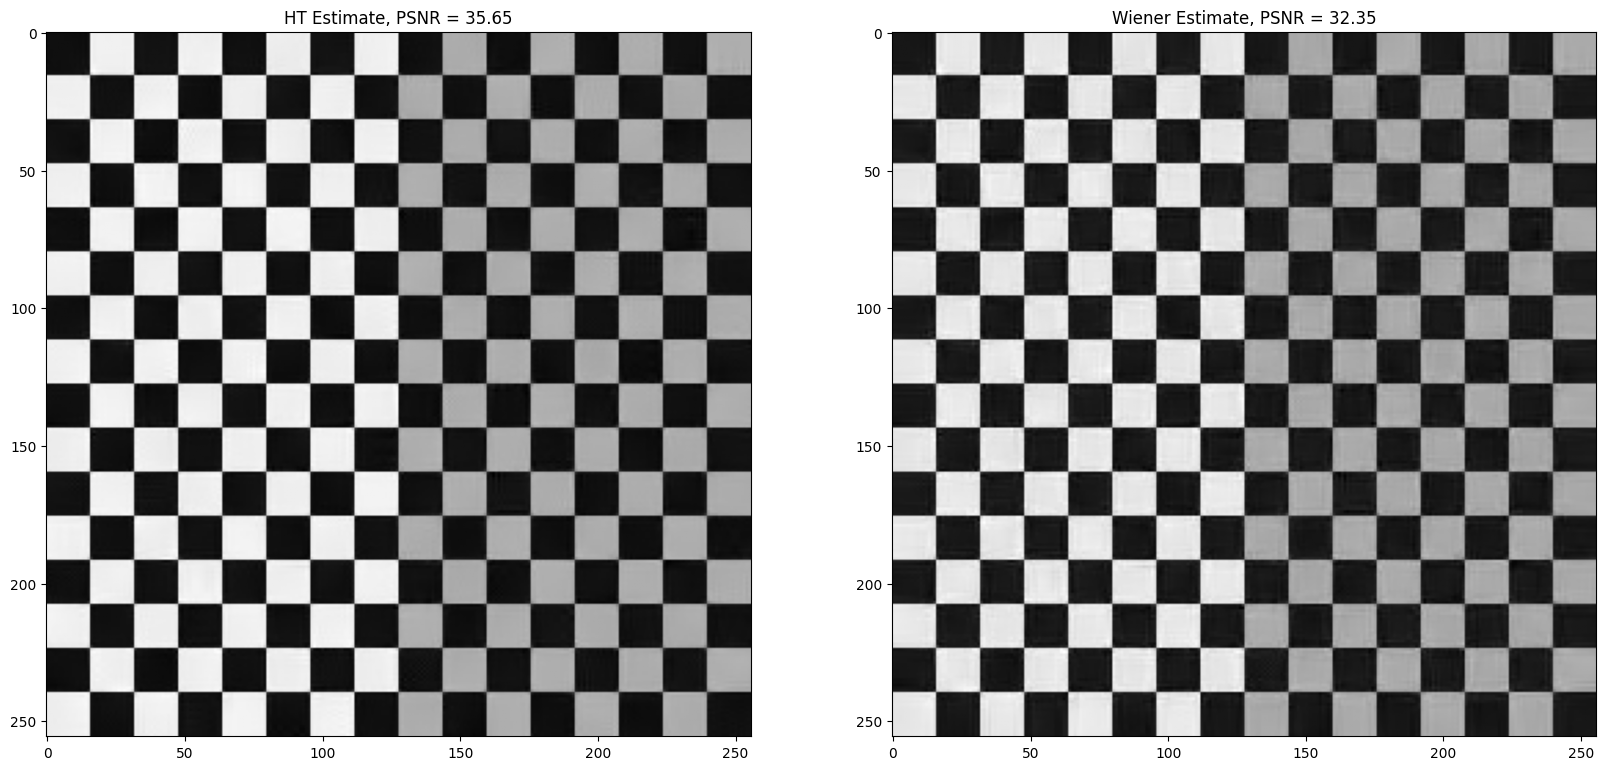

In [56]:
psnr_wiener = 10 * np.log10(1.0/np.square(np.subtract(img, img_hat_wiener)).mean())

fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(img_hat, cmap='gray')
ax[0].set_title(f'HT Estimate, PSNR = {psnr_hat:.2f}')

ax[1].imshow(img_hat_wiener, cmap='gray')
ax[1].set_title(f'Wiener Estimate, PSNR = {psnr_wiener:.2f}')